# Lecture 9: Fine-tuning for Classification

**Goal**: Adapt a pretrained language model to solve a classification task.

**Task**: Given a name, predict how many vowels (a, e, i, o, u) it contains.

### Key Concepts
- **Transfer learning**: reuse a model trained on one task (language modeling) for a different task (classification)
- **Classification head**: a small linear layer added on top of the pretrained backbone
- **Fine-tuning**: update all (or some) model weights on the new task’s data
- We treat vowel counting as a multi-class classification problem with 11 classes (0–10+)

## Load the Dataset
- We use a simple text file with one name per line (~32K names)
- Each name becomes an input; the label is computed from the name itself

In [1]:
# Load one name per line from the file.
data = open('names.txt').read().splitlines()

# Quick check of dataset size.
print(f"Total names: {len(data)}")

# Show a few examples from the middle.
data[1000:1010]


Total names: 32033


['paityn',
 'evalyn',
 'luz',
 'nathalia',
 'winnie',
 'chandler',
 'ciara',
 'danica',
 'nailah',
 'rilynn']

## Count Vowels — Label Construction
- Labels are derived automatically: count vowels in each name
- This is a deterministic function — no manual annotation needed
- We cap at 10 to keep the number of classes manageable

In [2]:
def count_vowels(name):
    # Return how many characters in this name are vowels.
    # Lowercasing makes counting case-insensitive.
    vowels = 'aeiou'
    return sum(1 for char in name.lower() if char in vowels)

# Simple demo of the helper function.
test_names = ['emma', 'olivia', 'charlotte', 'xyz', 'aaa']
for name in test_names:
    print(f"{name}: {count_vowels(name)} vowels")


emma: 2 vowels
olivia: 4 vowels
charlotte: 3 vowels
xyz: 0 vowels
aaa: 3 vowels


## Load the Pretrained Model & Tokenizer
- **SmolLM2-135M**: a small causal language model (~135M params)
- We add special tokens (`<|pad|>`, `<|startoftext|>`) the original model doesn’t have
- `resize_token_embeddings` extends the embedding matrix for new tokens
- The base model knows language structure; we leverage that for classification

In [3]:
# Import libraries for pretrained model loading and PyTorch training.
import transformers
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM

# Base language model that we will adapt for classification.
model_name = "HuggingFaceTB/SmolLM2-135M"

# Load tokenizer and model weights.
tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModelForCausalLM.from_pretrained(model_name)

# Add special tokens for padding and sequence start.
tokenizer.add_special_tokens({
    "pad_token": "<|pad|>",
    "bos_token": "<|startoftext|>",
})

# Because tokenizer vocabulary changed, resize model token embeddings.
base_model.resize_token_embeddings(len(tokenizer))

# Print parameter count so students know model scale.
print(f"Model parameters: {sum(p.numel() for p in base_model.parameters()):,}")


/opt/miniconda3/envs/anlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model parameters: 134,516,160


## Create Dataset & DataLoaders
- `VowelCountDataset`: wraps names + labels into a PyTorch `Dataset`
- `collate_fn`: tokenizes a batch together and pads to equal length
- Standard 80/10/10 split for train/dev/test
- **Key design choice**: labels are precomputed in `__init__` for speed

In [4]:
from torch.utils.data import Dataset, DataLoader
import random

class VowelCountDataset(Dataset):
    def __init__(self, names, tokenizer, max_length=32):
        # Save inputs needed for each example.
        self.names = names
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Precompute labels once for speed.
        # Label range is 0..10, where 10 means 10 or more vowels.
        self.labels = [min(count_vowels(name), 10) for name in names]

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        label = self.labels[idx]

        # Build text input with explicit BOS/EOS tokens.
        text = self.tokenizer.bos_token + name + self.tokenizer.eos_token

        return {
            'text': text,
            'label': label,
            'name': name  # Helpful for debugging.
        }

    def collate_fn(self, batch):
        # Collect fields from individual examples.
        texts = [item['text'] for item in batch]
        labels = torch.tensor([item['label'] for item in batch])

        # Tokenize as a batch and pad to equal length.
        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            'input_ids': inputs['input_ids'],
            'attention_mask': inputs['attention_mask'],
            'labels': labels
        }

# Split data into train/dev/test = 80/10/10.
random.seed(123)
random.shuffle(data)

n1 = int(0.8 * len(data))
n2 = int(0.9 * len(data))

train_data = data[:n1]
dev_data = data[n1:n2]
test_data = data[n2:]

print(f"Train: {len(train_data)}, Dev: {len(dev_data)}, Test: {len(test_data)}")

# Wrap splits with Dataset objects.
train_dataset = VowelCountDataset(train_data, tokenizer)
dev_dataset = VowelCountDataset(dev_data, tokenizer)
test_dataset = VowelCountDataset(test_data, tokenizer)

# DataLoaders provide shuffling and batching.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=train_dataset.collate_fn)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False, collate_fn=dev_dataset.collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=test_dataset.collate_fn)

# Peek one batch to verify format.
next(train_loader.__iter__())


Train: 25626, Dev: 3203, Test: 3204


{'input_ids': tensor([[49153, 44450,  1299,   337,     0, 49152],
         [49153,   257,   101,  1241,     0, 49152],
         [49153, 16427,   382,  5488,     0, 49152],
         [49153,  1140,    81,     0, 49152, 49152],
         [49153, 25616,   272,  1744,    94,     0],
         [49153,  2432,  1437,     0, 49152, 49152],
         [49153,  2292,    92,  1287,     0, 49152],
         [49153,  7483,   903,     0, 49152, 49152],
         [49153,    91,   576,   105,     0, 49152],
         [49153,    83,  3231,     0, 49152, 49152],
         [49153,    84,  1437, 18133,     0, 49152],
         [49153,   105,   336,     0, 49152, 49152],
         [49153,   322,  2889,   317,     0, 49152],
         [49153,   106,  1951,  1905,    81,     0],
         [49153,   344,  2554, 37602,     0, 49152],
         [49153, 22258,  1437,     0, 49152, 49152],
         [49153,    86,  9809,     0, 49152, 49152],
         [49153,    99,  1287,   272,   519,     0],
         [49153,   432,   672,  2

## Examine the Label Distribution
- Always inspect class balance before training
- Imbalanced classes can bias the model toward the majority class
- Most names have 2–3 vowels; very few have 0 or 6+

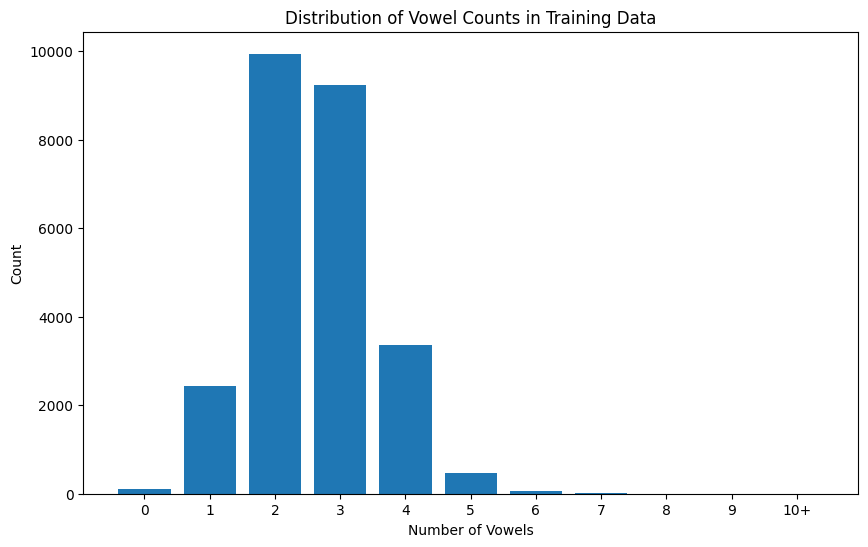

Vowels 0: 96 names (0.4%)
Vowels 1: 2435 names (9.5%)
Vowels 2: 9942 names (38.8%)
Vowels 3: 9238 names (36.0%)
Vowels 4: 3360 names (13.1%)
Vowels 5: 474 names (1.8%)
Vowels 6: 61 names (0.2%)
Vowels 7: 19 names (0.1%)
Vowels 8: 1 names (0.0%)
Vowels 9: 0 names (0.0%)
Vowels 10+: 0 names (0.0%)


In [5]:
import matplotlib.pyplot as plt
from collections import Counter

# Count how many training names belong to each class.
train_labels = [min(count_vowels(name), 10) for name in train_data]
label_counts = Counter(train_labels)

# Plot class distribution to inspect class imbalance.
plt.figure(figsize=(10, 6))
labels = list(range(11))
counts = [label_counts.get(i, 0) for i in labels]
plt.bar(labels, counts)
plt.xlabel('Number of Vowels')
plt.ylabel('Count')
plt.title('Distribution of Vowel Counts in Training Data')
plt.xticks(labels, [str(i) if i < 10 else '10+' for i in labels])
plt.show()

# Also print counts and percentages in text form.
for i in range(11):
    count = label_counts.get(i, 0)
    print(f"Vowels {i if i < 10 else '10+'}: {count} names ({count/len(train_data)*100:.1f}%)")


## Build the Classifier Model
- **Architecture**: Pretrained LM backbone → last-token hidden state → Linear head → class logits
- We extract the hidden state at the **last non-padding token** (not always the last position)
- `output_hidden_states=True` tells HuggingFace to return all layer outputs
- Only the classification head is new; the backbone is reused from pretraining

In [ ]:
class LMClassifier(nn.Module):
    def __init__(self, base_model, num_classes=11):
        super().__init__()
        # Reuse the pretrained language model backbone.
        self.base_model = base_model
        self.num_classes = num_classes
        self.hidden_size = base_model.config.hidden_size

        # Linear classification head: hidden vector -> class logits.
        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def _last_token_hidden(self, hidden_states, attention_mask):
        # Pick hidden state at the last non-padding token for each sequence.
        if attention_mask is not None:
            seq_lengths = attention_mask.sum(dim=1) - 1
            batch_size = hidden_states.size(0)
            last_hidden = hidden_states[torch.arange(batch_size), seq_lengths]
        else:
            # Fallback if no mask is available.
            last_hidden = hidden_states[:, -1, :]
        return last_hidden

    def forward(self, input_ids, attention_mask=None, labels=None):
        # labels is accepted for compatibility with calls in training loop.
        outputs = self.base_model(
            input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )

        # Use last transformer layer, then take last-token representation.
        hs = outputs.hidden_states[-1]  # (batch_size, seq_len, hidden_size)
        h_last = self._last_token_hidden(hs, attention_mask)

        # Convert features to class scores.
        logits = self.classifier(h_last)
        return logits


## Training & Evaluation Functions
- Standard PyTorch loop: forward → loss → backward → optimizer step
- `CrossEntropyLoss` is the standard loss for multi-class classification
- `torch.no_grad()` in evaluation saves memory and speeds up inference
- We track both loss and accuracy per epoch

In [7]:
import torch.optim as optim
from tqdm import tqdm

def train_epoch(model, loss_fn, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc="Training")
    for batch_idx, batch in enumerate(progress_bar):
        # Move tensors to selected device (CPU/GPU).
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Reset gradients from previous step.
        optimizer.zero_grad()

        # Forward pass + classification loss.
        logits = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = loss_fn(logits, labels)

        # Backpropagation + parameter update.
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Track running accuracy.
        predictions = torch.argmax(logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        # Show per-batch and running metrics.
        avg_loss = total_loss / (batch_idx + 1)
        accuracy = correct / total
        progress_bar.set_postfix({
            'batch_loss': f'{loss.item():.4f}',
            'avg_loss': f'{avg_loss:.4f}',
            'batch_acc': f'{(predictions == labels).sum().item()/labels.size(0)}',
            'avg_acc': f'{accuracy:.4f}'
        })

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate(model, loss_fn, dataloader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # No gradients during evaluation.
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = loss_fn(logits, labels)

            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

# Use GPU if available, else CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## Run Fine-Tuning
- **Full fine-tuning**: all 134M+ parameters are updated (backbone + head)
- Learning rate `1e-5` — small to avoid destroying pretrained knowledge
- `CosineAnnealingLR` scheduler smoothly decays the learning rate
- Only 2 epochs needed — pretrained features transfer well to this task

In [ ]:
# Number of classes (0..10, where 10 = 10+ vowels).
MAX_VOWELS = 11

# Create model and move to device.
model = LMClassifier(base_model, num_classes=MAX_VOWELS)
model = model.to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Main hyperparameters.
learning_rate = 1e-5
num_epochs = 2

# Optimizer + scheduler + loss function.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
loss_fn = nn.CrossEntropyLoss()

print("\nFine-tuning entire model")
print("="*50)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, loss_fn, train_loader, optimizer, device)
    val_loss, val_acc = evaluate(model, loss_fn, dev_loader, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Update LR schedule each epoch.
    scheduler.step()


Trainable parameters: 134,522,507

Fine-tuning entire model


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Evaluating: 100%|██████████| 101/101 [00:08<00:00, 11.51it/s]


Epoch 1/2
  Train Loss: 0.6852, Train Acc: 0.7433
  Val Loss: 0.1599, Val Acc: 0.9603


Evaluating: 100%|██████████| 101/101 [00:09<00:00, 10.81it/s]

Epoch 2/2
  Train Loss: 0.1021, Train Acc: 0.9726
  Val Loss: 0.1014, Val Acc: 0.9716


## Evaluate on Test Set
- Final, unbiased estimate of model performance
- Test set was **never** used during training or hyperparameter tuning
- Report both loss and accuracy

In [9]:
# Final evaluation on test set.
test_loss, test_acc = evaluate(model, loss_fn, test_loader, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Evaluating: 100%|██████████| 101/101 [00:08<00:00, 11.24it/s]

Test Loss: 0.1049
Test Accuracy: 0.9685


## Confusion Matrix
- Shows where the model confuses one class for another
- Diagonal = correct; off-diagonal = errors
- Useful for spotting systematic biases (e.g., always predicting the majority class)
- Per-class accuracy reveals performance on rare classes

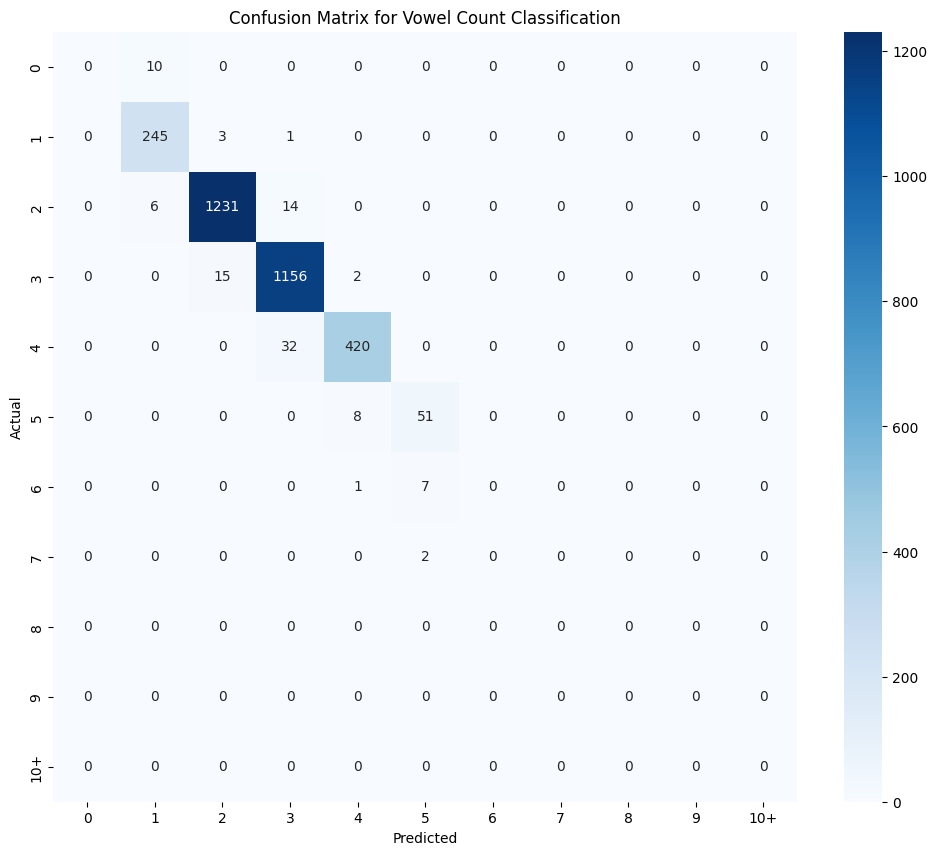

Class 0: 0.000 (10 samples)
Class 1: 0.984 (249 samples)
Class 2: 0.984 (1251 samples)
Class 3: 0.986 (1173 samples)
Class 4: 0.929 (452 samples)
Class 5: 0.864 (59 samples)
Class 6: 0.000 (8 samples)
Class 7: 0.000 (2 samples)


In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Collect predictions and true labels over the whole test set.
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        logits = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(logits, dim=-1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Build confusion matrix for classes 0..10.
cm = confusion_matrix(all_labels, all_predictions, labels=list(range(11)))

# Plot confusion matrix as a heatmap.
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) if i < 10 else '10+' for i in range(11)],
            yticklabels=[str(i) if i < 10 else '10+' for i in range(11)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Vowel Count Classification')
plt.show()

# Print per-class accuracy (within each actual class).
for i in range(11):
    if cm[i].sum() > 0:
        class_acc = cm[i, i] / cm[i].sum()
        print(f"Class {i if i < 10 else '10+'}: {class_acc:.3f} ({cm[i].sum()} samples)")


## Example Predictions & Error Analysis
- Qualitative check: hand-picked names + adversarial examples (e.g., "xyz", "rhythm")
- The model struggles with names that have 0 vowels — rare in training data
- **Takeaway**: model performance is closely tied to label distribution

In [11]:
def predict_vowel_count(model, name, tokenizer, device):
    # Predict vowel-count class for one name.
    model.eval()

    # Match training input format.
    text = tokenizer.bos_token + name + tokenizer.eos_token
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=32)

    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask=attention_mask)
        prediction = torch.argmax(logits, dim=-1).item()

    return prediction

# Hand-picked examples for quick sanity checks.
test_names = [
    'emma', 'olivia', 'noah', 'william', 'isabella',
    'james', 'charlotte', 'benjamin', 'mia', 'theodore',
    'xyz', 'bcd', 'aeiou', 'rhythm', 'sky'
]

print("Name		Actual	Predicted	Correct")
print("="*50)

for name in test_names:
    actual = min(count_vowels(name), 10)
    predicted = predict_vowel_count(model, name, tokenizer, device)
    correct = "✓" if actual == predicted else "✗"
    print(f"{name:12}	{actual}	{predicted}		{correct}")


Name		Actual	Predicted	Correct
emma        	2	2		✓
olivia      	4	4		✓
noah        	2	2		✓
william     	3	3		✓
isabella    	4	4		✓
james       	2	2		✓
charlotte   	3	3		✓
benjamin    	3	3		✓
mia         	2	2		✓
theodore    	4	4		✓
xyz         	0	1		✗
bcd         	0	1		✗
aeiou       	5	4		✗
rhythm      	0	1		✗
sky         	0	1		✗


In [ ]:
# Find and display misclassified examples for error analysis.
model.eval()
errors = []
correct_examples = []

num_checked = min(250, len(test_data))
with torch.no_grad():
    for i in range(num_checked):
        name = test_data[i]
        actual = min(count_vowels(name), 10)
        predicted = predict_vowel_count(model, name, tokenizer, device)

        if actual != predicted:
            errors.append((name, actual, predicted))
        else:
            correct_examples.append((name, actual))

print(f"Errors: {len(errors)} / {num_checked}")
print("\nSome misclassified examples:")
print("Name\t\tActual\tPredicted")
print("="*35)

for name, actual, predicted in errors[:15]:
    print(f"{name:12}	{actual}	{predicted}")


Errors: 9 / 100

Some misclassified examples:
Name		Actual	Predicted
anthony     	2	3
million     	3	2
sherly      	1	2
sylvester   	2	3
esequiel    	5	4
aaradhya    	4	3
brynn       	0	1
taliesin    	4	3
aceion      	4	3
